# Detección de personas y vehículos desde drones
### Trabajo práctico 4 · Visión artificial
**VisDrone2019-DET · YOLO · Transfer learning**

## Resumen
Se estudia la adaptación de un detector de objetos a imágenes aéreas mediante aprendizaje por transferencia. Se utiliza VisDrone2019-DET, con diez categorías y particiones oficiales, y una variante compacta de YOLO inicializada con pesos preentrenados. La arquitectura y sus parámetros se identifican en el protocolo de cada evaluación. Se consideran precisión, exhaustividad, calidad de localización y coste de inferencia. Luego el trabajo se orienta a una misión embarcada en un dron: dos clases (persona y vehículo), un objetivo de detección durante la pasada, la comparación de resoluciones de entrada y una demostración en video.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

ROOT = Path(os.environ.get('TP4_ROOT', Path.cwd())).resolve()
if not (ROOT / 'config.yaml').exists() and (ROOT.parent / 'config.yaml').exists():
    ROOT = ROOT.parent

# Colab puede abrir el .ipynb directamente desde GitHub, sin clonar el resto del proyecto.
try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except ImportError:
    IS_COLAB = False
if IS_COLAB and not (ROOT / 'config.yaml').exists():
    # Trae código y resultados versionados (JSON, figuras y video de la demo); no hace falta el dataset.
    ROOT = Path('/content/tp4-visdrone-yolo')
    if not (ROOT / '.git').exists():
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/miroagustin/tp4-visdrone-yolo.git', str(ROOT)], check=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from tp4 import notebook_view as view

RUN_ID = None
ctx = view.context(ROOT, RUN_ID, final_only=True)

## 1. Introducción
La percepción visual desde drones combina cambios de escala, perspectiva elevada, oclusión y alta densidad de objetos. Una persona o un vehículo puede ocupar pocos píxeles, lo que dificulta tanto su clasificación como la ubicación precisa de su contorno.

La detección devuelve una categoría, una caja y una confianza por objeto. En robótica, esta información puede alimentar seguimiento, conteo y análisis de escenas. El alcance de este trabajo es la detección en imágenes estáticas.

**Preguntas de investigación:** ¿qué capacidad de detección presenta un modelo compacto de YOLO al adaptarse a las categorías de VisDrone y qué limitaciones revelan sus errores? ¿Qué configuración permite cumplir una misión de detección a bordo de un dron?

## 2. Objetivos y fundamento del modelo
El objetivo es adaptar un detector pequeño a imágenes aéreas y caracterizar su desempeño mediante métricas globales, resultados por clase y análisis visual.

YOLO predice cajas y categorías en una pasada. Las variantes nano de YOLO11 y YOLO26 permiten estudiar detectores de tamaño y coste computacional reducidos [3]. El aprendizaje por transferencia reutiliza representaciones aprendidas en COCO y adapta la red a las diez categorías de VisDrone. La tabla metodológica identifica el modelo utilizado en los resultados presentados.

La hipótesis es que las representaciones preentrenadas aportan características útiles, mientras que la baja resolución de los objetos y las oclusiones limitan la detección. Su interpretación depende del presupuesto de entrenamiento y de la evidencia observada.

## 3. Datos y anotaciones
VisDrone2019-DET contiene imágenes aéreas con personas y vehículos en escenarios urbanos y rurales [1, 2]. Se conservaron sus particiones oficiales. El entrenamiento ajusta los pesos, la validación permite seleccionar el modelo y test-dev constituye una partición independiente.

La auditoría comprueba la correspondencia entre imágenes y anotaciones, las dimensiones de las cajas y los índices de clase.

In [2]:
view.dataset_table(ctx)

| Partición | Imágenes auditadas | Cajas válidas | Score 0 excluido | Uso |
|---|---|---|---|---|
| train | 6471 | 343204 | 10345 | Ajustar pesos |
| val | 548 | 38759 | 1410 | Seleccionar / diagnosticar |
| test-dev | 1610 | 75102 | 2445 | Evaluación y seguimiento cualitativo |

**Control de calidad:** se excluyeron 1 cajas con tamaño inválido. Se conservaron las imágenes y anotaciones originales.

### Representación de las clases
| Categoría original → YOLO | Clase | Categoría original → YOLO | Clase |
|---|---|---|---|
| 1 → 0 | pedestrian | 6 → 5 | truck |
| 2 → 1 | people | 7 → 6 | tricycle |
| 3 → 2 | bicycle | 8 → 7 | awning-tricycle |
| 4 → 3 | car | 9 → 8 | bus |
| 5 → 4 | van | 10 → 9 | motor |

`pedestrian` corresponde a personas de pie o caminando; `people` incluye otras posturas [2]. Se conservaron las anotaciones con score 1 y categoría entre 1 y 10. Las regiones con score 0 se excluyeron, así como las cajas de tamaño inválido.

Para una imagen de dimensiones W×H, la caja original `(x,y,w,h)` se expresa como `((x+w/2)/W, (y+h/2)/H, w/W, h/H)`. Por ejemplo, `(100,50,200,100)` en una imagen de 1000×500 produce `(0.2,0.2,0.2,0.2)`.

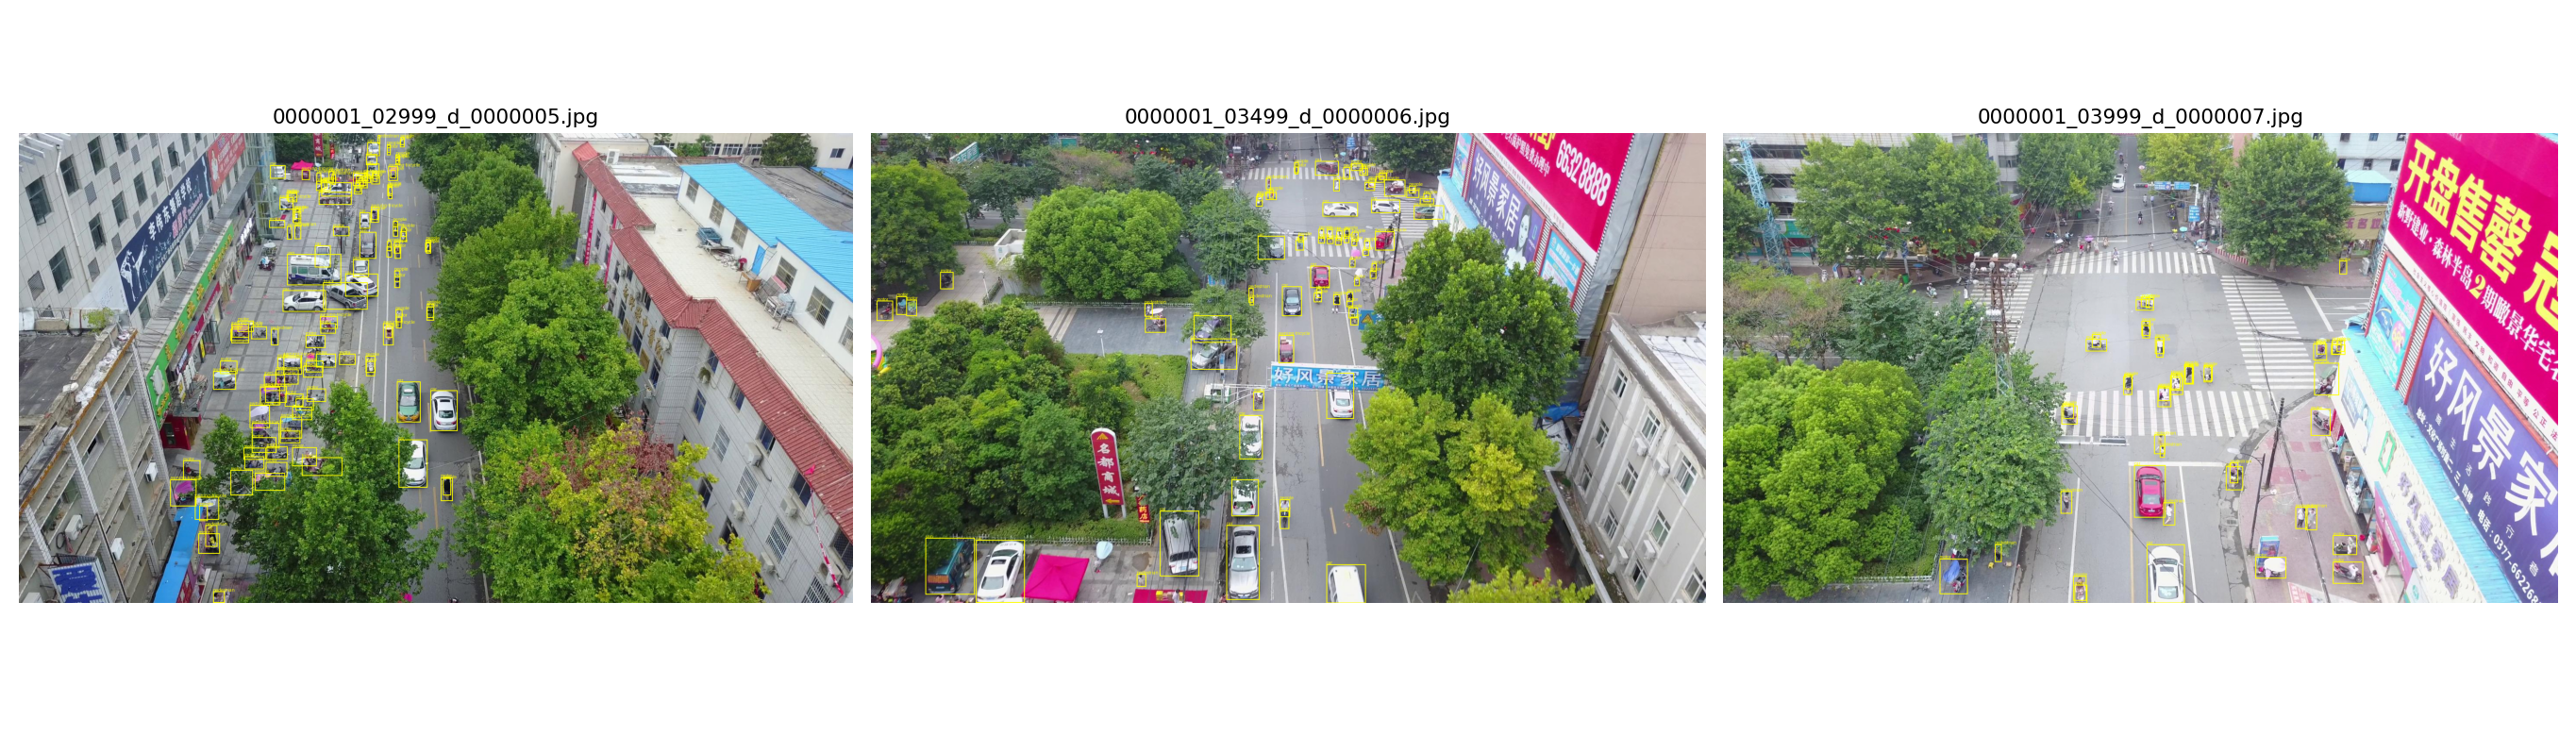

*Figura 1. Cajas convertidas sobre tres imágenes de validación. La revisión visual complementa los controles automáticos.*

In [3]:
view.figure(ctx, 'data/box_review.png', 'Figura 1. Cajas convertidas sobre tres imágenes de validación. La revisión visual complementa los controles automáticos.')

### Distribución de clases y tamaños
El número de anotaciones por clase describe el desbalance del conjunto. El cociente entre el área de cada caja y el área de la imagen caracteriza el tamaño relativo de los objetos.

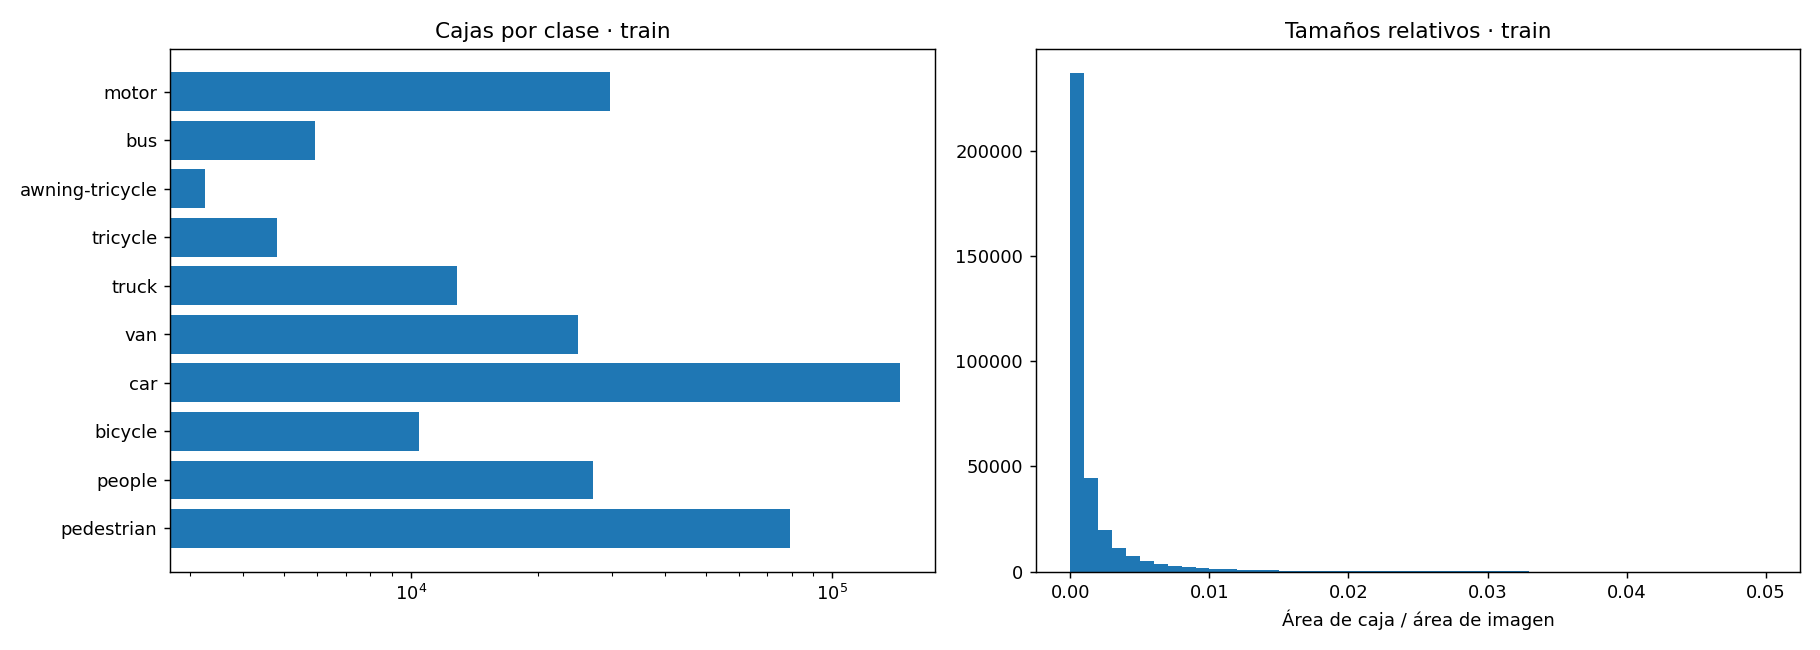

*Figura 2. Distribución de clases y áreas relativas en train. El histograma representa el intervalo indicado en su eje horizontal.*

In [4]:
view.figure(ctx, 'data/audit.png', 'Figura 2. Distribución de clases y áreas relativas en train. El histograma representa el intervalo indicado en su eje horizontal.')

## 4. Metodología experimental
Se utilizó aprendizaje por transferencia y una semilla fija. Las particiones oficiales se conservaron durante el procesamiento. La selección del checkpoint se realizó con validación; todas las cifras de una evaluación provienen del mismo modelo y protocolo.

La tabla presenta el presupuesto de entrenamiento y el entorno correspondientes a los resultados analizados.

In [5]:
view.protocol(ctx)

| Variable | Configuración experimental |
|---|---|
| Modelo / inicialización | yolo26n.pt · pesos preentrenados COCO |
| Épocas configuradas | 50 |
| Train / val | split completo / split completo imágenes |
| Resolución / batch / semilla | 640 px / 4 / 42 |
| GPU | NVIDIA GeForce RTX 5070 Laptop GPU |
| PyTorch / Ultralytics | 2.13.0+cu130 / 8.4.162 |

### Ajuste y selección del modelo
El entrenamiento actualiza los pesos con las imágenes de train. La evaluación utiliza el checkpoint seleccionado por el procedimiento de validación de Ultralytics. El núcleo de ambas operaciones se expresa a continuación.

In [6]:
def ajustar_y_evaluar(configuracion, directorio):
    from ultralytics import YOLO
    from tp4.experiment import device_or_raise
    dispositivo = device_or_raise(configuracion['device'])
    modelo = YOLO(configuracion['model'])
    from tp4.epoch_preview import attach_epoch_preview
    attach_epoch_preview(modelo, configuracion, directorio)
    modelo.train(
        data=configuracion['data_yaml'], epochs=configuracion['epochs'],
        imgsz=configuracion['imgsz'], batch=configuracion['batch'],
        workers=configuracion['workers'], seed=configuracion['seed'],
        device=dispositivo, project=str(directorio), name='train',
    )
    checkpoint = Path(directorio) / 'train' / 'weights' / 'best.pt'
    return YOLO(str(checkpoint)).val(
        data=configuracion['data_yaml'], split='val',
        imgsz=configuracion['imgsz'], batch=configuracion['batch'],
        workers=configuracion['workers'], device=dispositivo,
    )

### Predicciones a lo largo del entrenamiento
Al finalizar cada época se selecciona de forma aleatoria reproducible una imagen de **test-dev**, ajena a train y val, y se muestran las detecciones de los pesos EMA de esa época con confianza mínima 0,25. Cada salida conserva la época y el nombre de la imagen. La secuencia permite explorar el comportamiento de la red; al cambiar de escena, las diferencias visuales no equivalen a una medida de mejora.

Este seguimiento utiliza imágenes de test-dev sin sus etiquetas y sin actualizar pesos con ellas. En las ejecuciones que lo activan, test-dev es un conjunto observado durante el entrenamiento; su evaluación posterior debe interpretarse con esa limitación.

In [ ]:
from tp4.epoch_preview import show_history

RUN_EVOLUTION = RUN_ID
WATCH_EPOCHS = False
show_history(ROOT, run=RUN_EVOLUTION, watch=WATCH_EPOCHS)

## 5. Criterios de evaluación
Una detección correcta requiere acertar la clase y alcanzar el solapamiento exigido. La **IoU** es el cociente entre el área de intersección y el área de unión de las cajas.

| Métrica | Definición | Interpretación |
|---|---|---|
| Precision | TP / (TP + FP) | Proporción de predicciones correctas |
| Recall | TP / (TP + FN) | Proporción de objetos encontrados |
| mAP@0.5 | Media entre clases del área bajo la curva precision–recall, con IoU 0,5 | Calidad de detección con localización moderada |
| mAP@0.5:0.95 | Media entre clases y diez umbrales de IoU de 0,50 a 0,95 | Exigencia mayor sobre la localización |

Se emplea el evaluador estándar de Ultralytics. Excluir etiquetas de regiones ignoradas no reproduce necesariamente el tratamiento del evaluador oficial de VisDrone; las cifras no se presentan como resultados oficiales de ese benchmark.

## 6. Resultados de validación
Las métricas se expresan como porcentajes y se interpretan bajo el protocolo descrito. Precision y recall resumen el punto de operación del evaluador, mientras que AP integra distintos umbrales de confianza.

In [8]:
view.metrics(ctx)

| Evaluación | Precision (%) | Recall (%) | mAP@0.5 (%) | mAP@0.5:0.95 (%) |
|---|---|---|---|---|
| Validación | 40.4115 | 31.7697 | 28.4536 | 15.8542 |

Porcentajes sobre la validación de esta ejecución. P/R agregadas por el evaluador; no corresponden necesariamente al umbral 0,25 de la galería. Métricas estándar de Ultralytics, no del evaluador oficial VisDrone.

### Resultados por clase
El desglose permite identificar diferencias entre categorías. Estas diferencias se consideran junto con su frecuencia en el conjunto y los ejemplos de detección.

In [9]:
view.metrics(ctx, per_class=True)

| Clase | Precision (%) | Recall (%) | mAP@0.5 (%) | mAP@0.5:0.95 (%) |
|---|---|---|---|---|
| pedestrian | 40.1752 | 36.3976 | 31.4710 | 12.9329 |
| people | 40.6764 | 26.0293 | 22.7001 | 7.3156 |
| bicycle | 19.4139 | 11.6550 | 6.2667 | 2.1987 |
| car | 57.2615 | 73.9619 | 70.6203 | 46.2251 |
| van | 43.0952 | 32.6582 | 31.5560 | 21.5320 |
| truck | 44.2787 | 28.5333 | 27.2269 | 17.2068 |
| tricycle | 37.6786 | 20.8612 | 18.0991 | 9.5906 |
| awning-tricycle | 26.8042 | 14.0977 | 8.8055 | 5.2296 |
| bus | 51.0498 | 37.0518 | 36.0528 | 24.0906 |
| motor | 43.6819 | 36.4511 | 31.7375 | 12.2196 |

Porcentajes sobre la validación de esta ejecución. P/R agregadas por el evaluador; no corresponden necesariamente al umbral 0,25 de la galería. Métricas estándar de Ultralytics, no del evaluador oficial VisDrone.

### Evolución del ajuste y matriz de confusión
Las curvas describen la evolución de pérdidas y métricas a lo largo del entrenamiento. La matriz resume asociaciones entre clases y errores con el fondo para la validación del modelo.

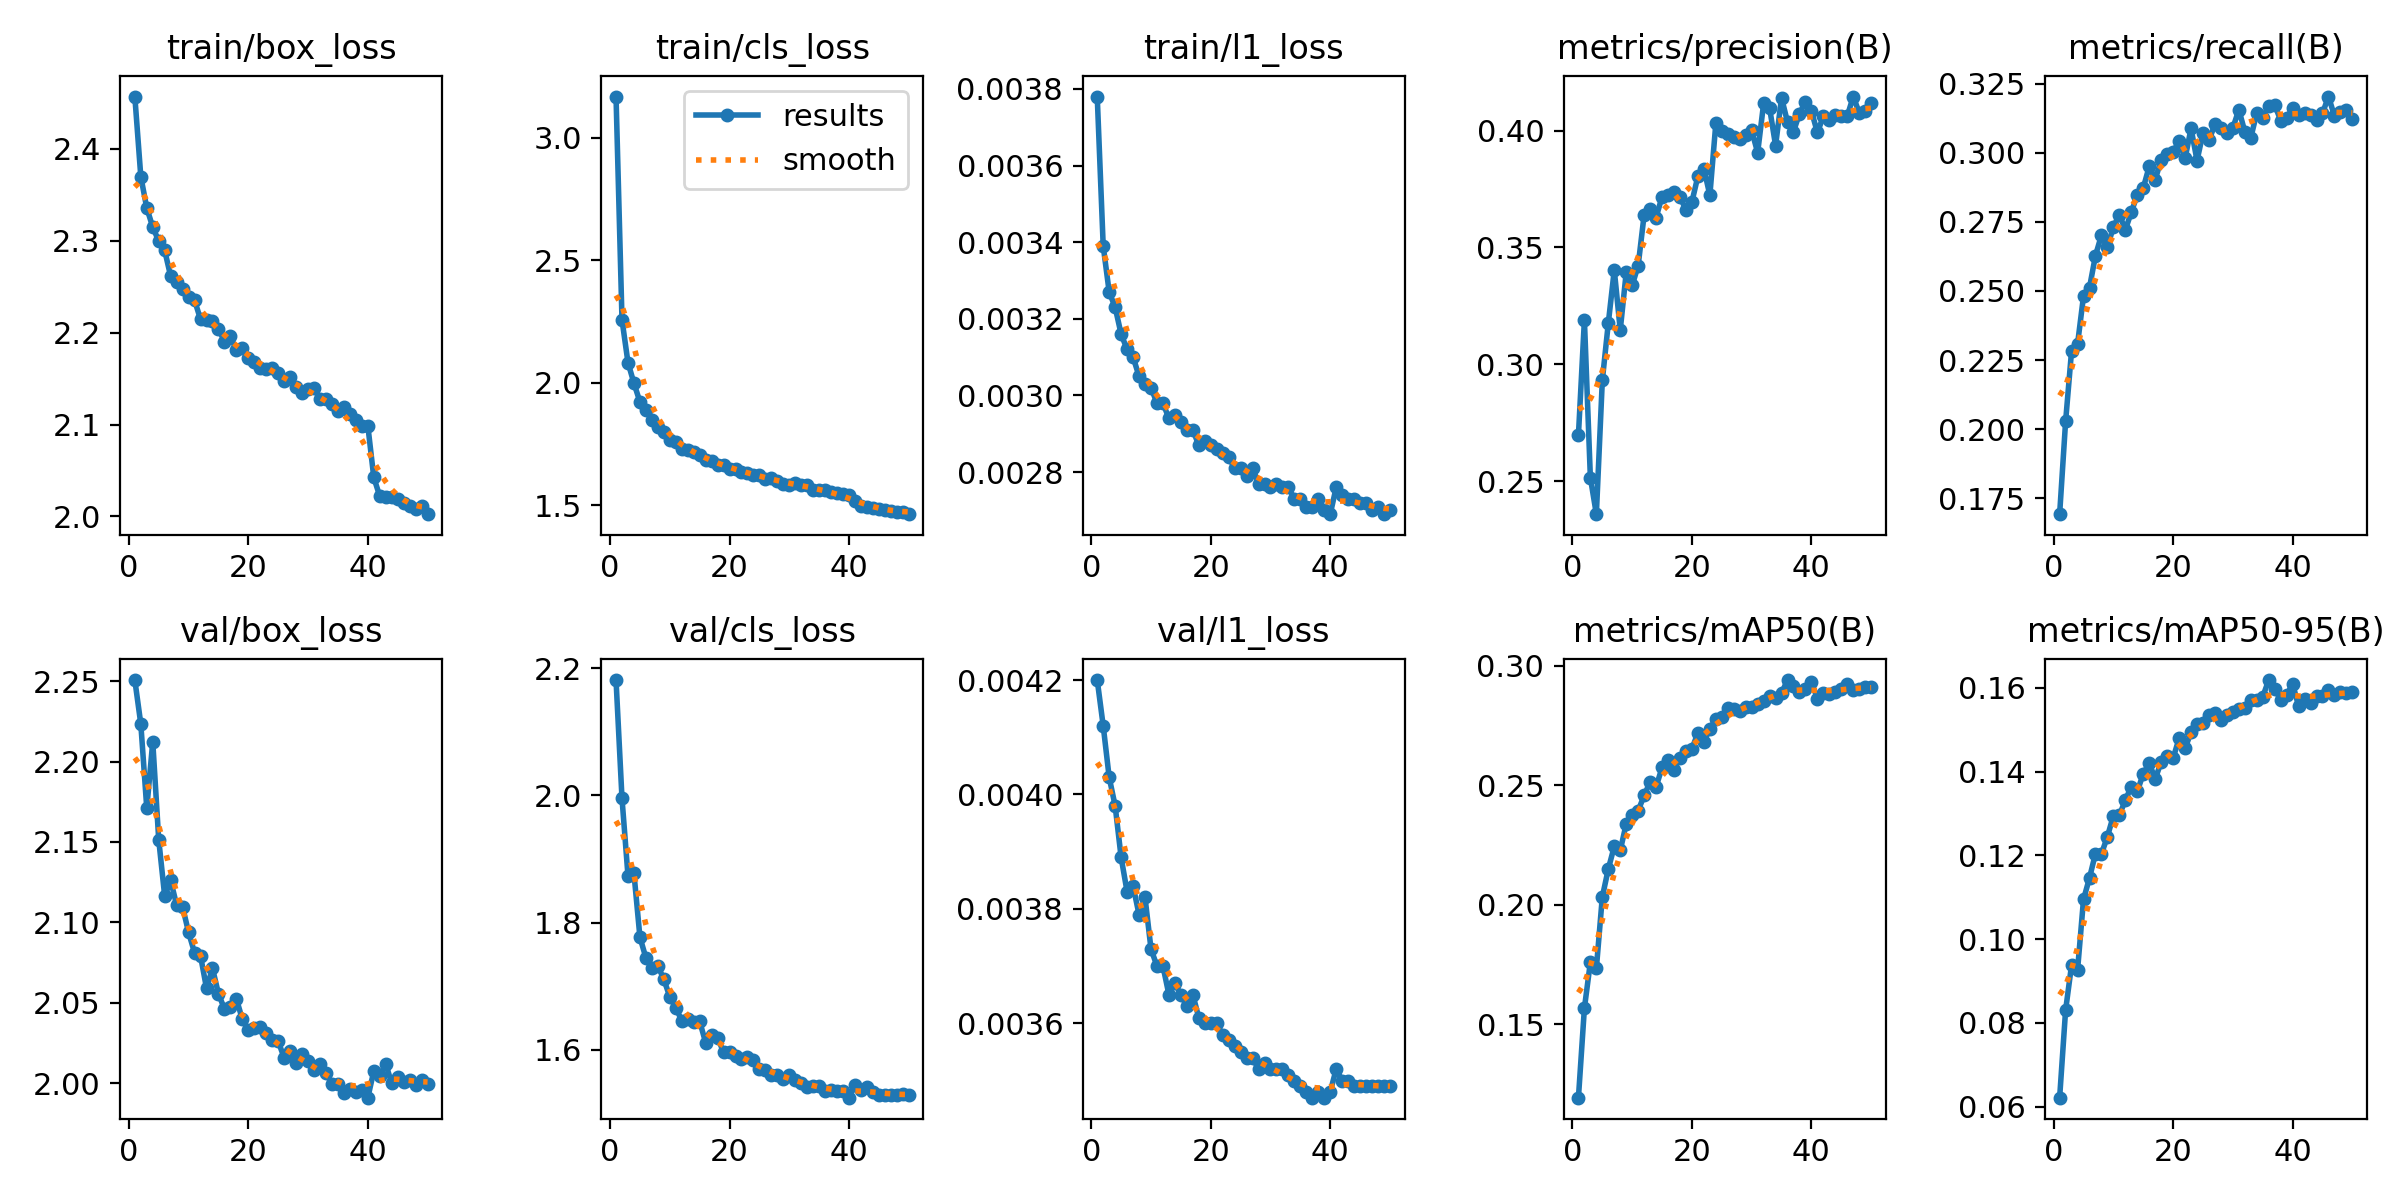

*Figura 3. Pérdidas de entrenamiento y evolución de las métricas de validación.*

In [10]:
view.figure(ctx, 'train/results.png', 'Figura 3. Pérdidas de entrenamiento y evolución de las métricas de validación.', run=True)

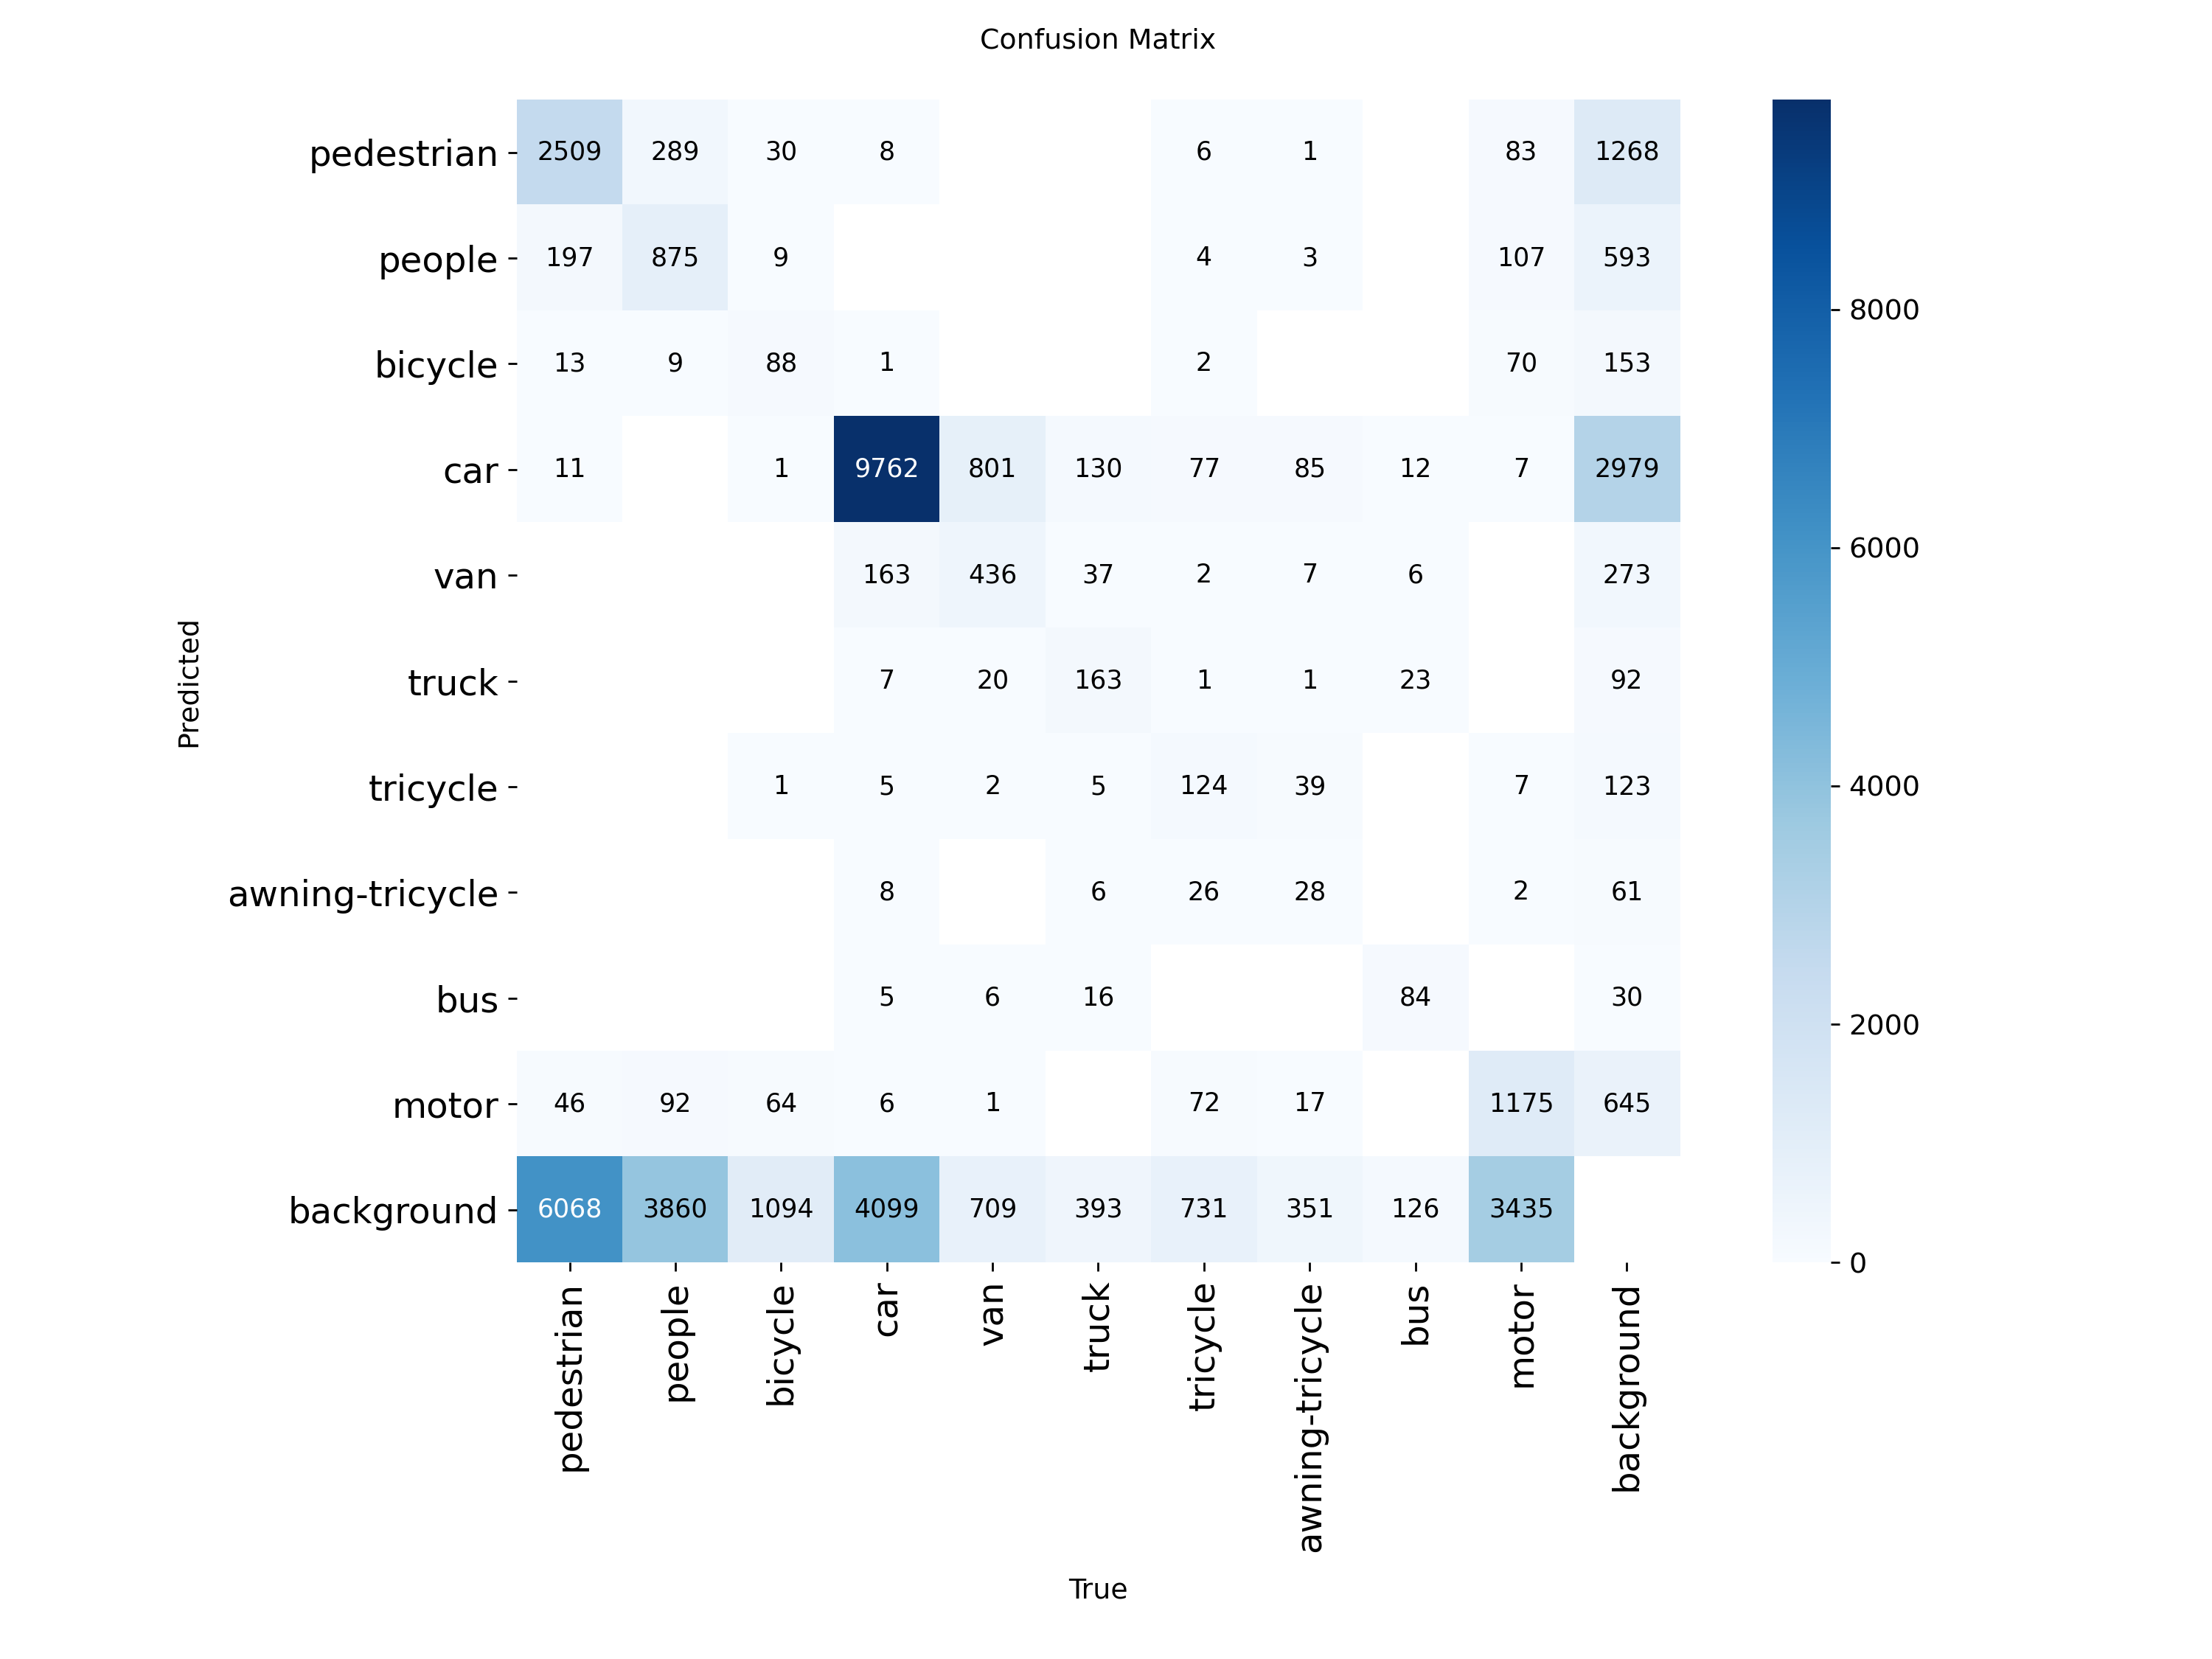

*Figura 4. Matriz de confusión del evaluador Ultralytics sobre validación.*

In [11]:
view.figure(ctx, 'validation/confusion_matrix.png', 'Figura 4. Matriz de confusión del evaluador Ultralytics sobre validación.', run=True)

## 7. Análisis de errores
El análisis de ejemplos de validación utiliza confianza 0,25 y asociación uno a uno por clase e IoU 0,5. Los conteos corresponden a una muestra de imágenes y no equivalen al mAP, que integra un barrido de confianza.

In [12]:
view.errors(ctx)

| Imágenes | Confianza | IoU de asociación | TP | FP | FN |
|---|---|---|---|---|---|
| 8 | 0.25 | 0.5 | 251 | 151 | 620 |

Asociación uno a uno, misma clase e IoU ≥ umbral. Son conteos de una muestra, no métricas de todo el conjunto.

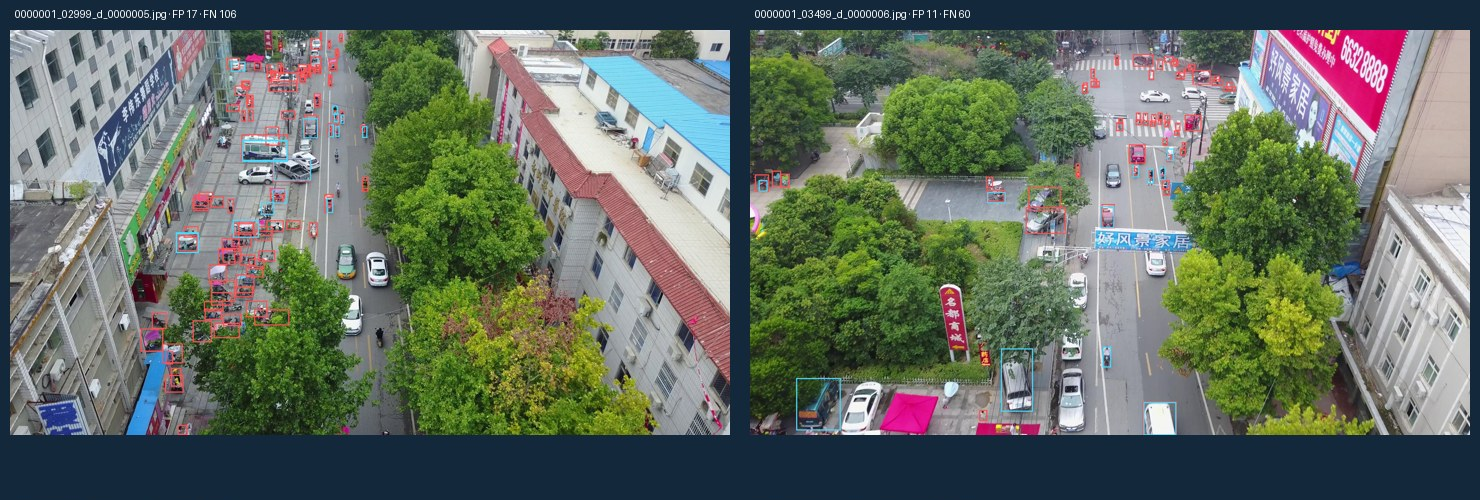

*Figura 5. Dos ejemplos de la muestra analizada: rojo indica falsos negativos y cian, falsos positivos.*

In [13]:
view.figure(ctx, 'error_gallery.jpg', 'Figura 5. Dos ejemplos de la muestra analizada: rojo indica falsos negativos y cian, falsos positivos.', run=True, first_row=True)

### Comparación visual con las anotaciones
La comparación del mismo lote muestra diferencias de ubicación, categoría y cobertura entre las anotaciones y las predicciones.

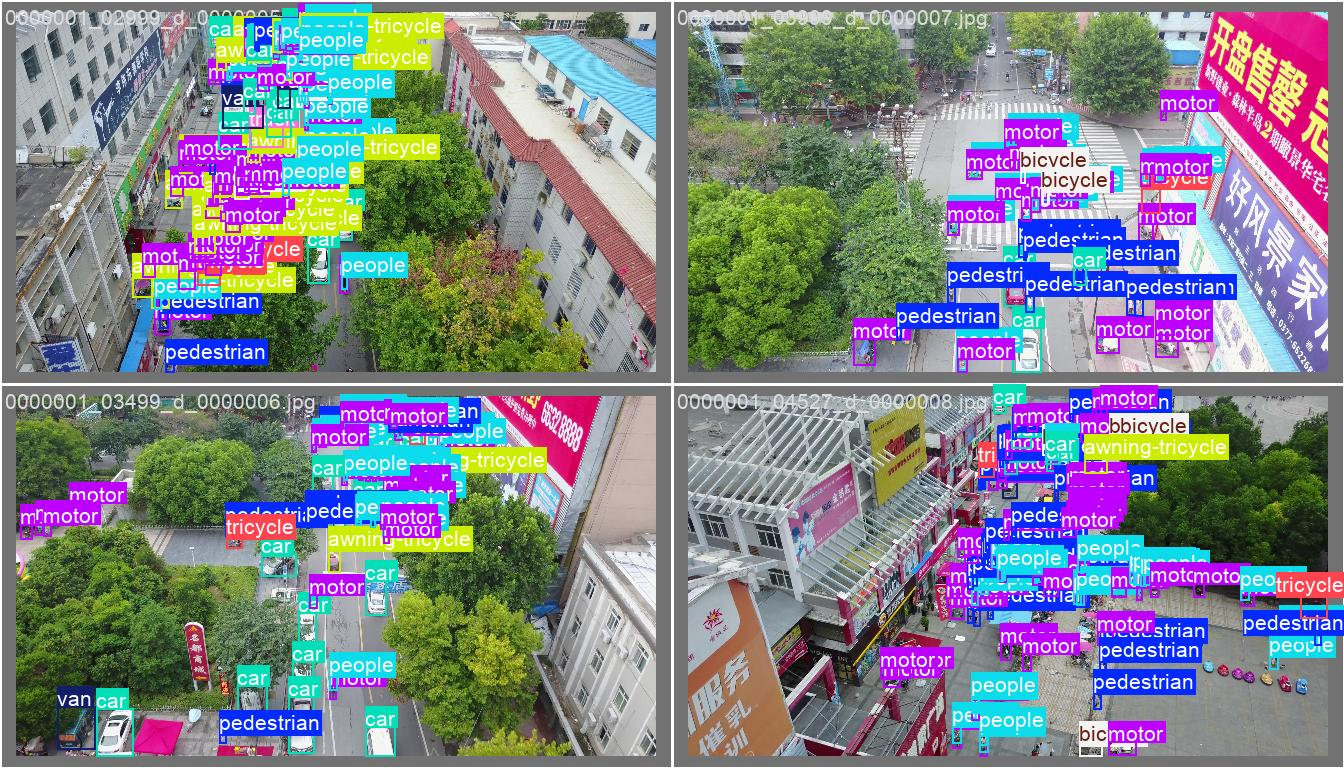

*Figura 6. Anotaciones de referencia del primer lote de validación.*

In [14]:
view.figure(ctx, 'validation/val_batch0_labels.jpg', 'Figura 6. Anotaciones de referencia del primer lote de validación.', run=True)

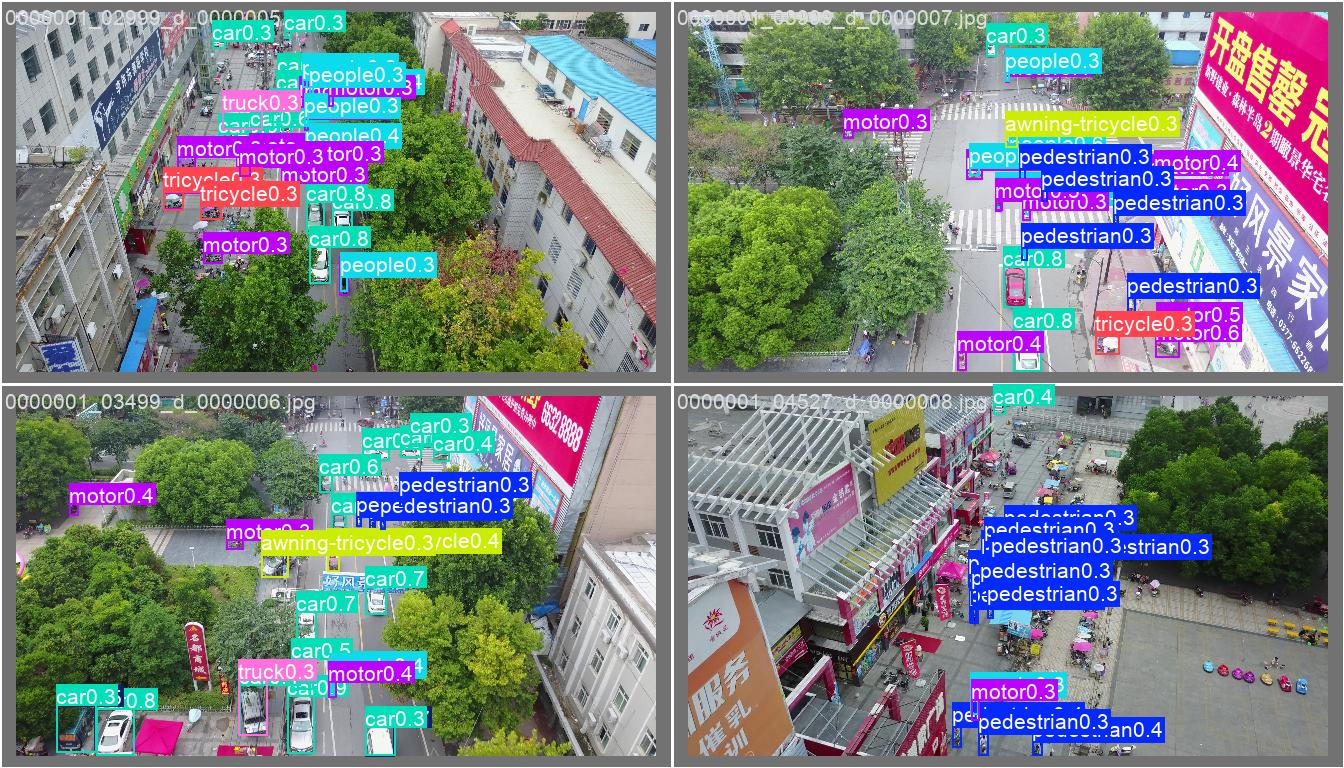

*Figura 7. Predicciones correspondientes al mismo lote de validación.*

In [15]:
view.figure(ctx, 'validation/val_batch0_pred.jpg', 'Figura 7. Predicciones correspondientes al mismo lote de validación.', run=True)

## 8. Coste de inferencia
La latencia corresponde a una llamada completa de predicción, con batch 1, calentamiento y sincronización CUDA. La medición caracteriza el entorno local utilizado.

In [16]:
view.latency(ctx)

| Tiempo por imagen | GPU | Resolución / batch | Calentamiento / repeticiones |
|---|---|---|---|
| 26.74 ms | NVIDIA GeForce RTX 5070 Laptop GPU | 640 / 1 | 5 / 20 |

Condición: predict completo, una imagen repetida. Una imagen repetida no representa la variabilidad de escenas ni el rendimiento en un dron.

## 9. Del laboratorio al dron: clases y objetivo
A bordo de un dron importa distinguir personas de vehículos, no las diez categorías de VisDrone. Las clases se agrupan en **persona** y **vehículo**, y se fija un objetivo operativo:

**Detectar al menos una vez durante la pasada el 85 % de las personas, con el modelo optimizado a 5 FPS o más en la placa.**

A 10 m/s, 5 FPS equivale a 2 m recorridos entre detecciones.

In [17]:
view.mission_classes(ctx)

| Clase de la misión | Clases VisDrone | Objetos (val) | AP50 | Precisión / recall por cuadro |
|---|---|---|---|---|
| persona | pedestrian, people | 13969 | 34,6 % | 65,3 % / 27,7 % |
| vehiculo | car, van, truck, bus, tricycle, awning-tricycle, bicycle, motor | 24790 | 63,0 % | 77,3 % / 54,2 % |

Mismo modelo de 10 clases, reagrupado después de la inferencia (640 px, confianza 0,25, IoU 0,5). El conductor de una moto o bicicleta está anotado como persona; el vehículo que conduce, como vehículo.

## 10. Resolución de entrada
Al reducir la imagen a 640 px, casi la mitad de las personas mide menos de 8 px y el modelo prácticamente no las detecta. Sin reentrenar, se probó procesar la imagen completa a mayor resolución y cortarla en mosaicos al estilo de SAHI [4].

In [18]:
view.resolution(ctx)

| Variante | Inferencias por imagen | ms por imagen (laptop) | mAP50 misión | Recall persona | Recall vehículo |
|---|---|---|---|---|---|
| Imagen completa 640 px | 1,0 | 16 | 48,4 % | 27,2 % | 54,3 % |
| Imagen completa 960 px | 1,0 | 17 | 57,0 % | 37,4 % | 63,0 % |
| Imagen completa 1280 px | 1,0 | 19 | 61,4 % | 42,9 % | 65,9 % |
| Mosaicos nativos | 6,2 | 54 | 55,8 % | 45,2 % | 70,4 % |
| Mosaicos nativos + 1280 px | 6,2 | 61 | 61,0 % | 48,0 % | 71,6 % |

Mismo `best.pt`, sin reentrenar, en las 548 imágenes de validación de DET. Recall por cuadro con confianza 0,25. El tiempo es de la GPU de la laptop: en una placa el costo crece cerca de la cantidad de píxeles.

## 11. Detección durante la pasada
En video, cada persona aparece en muchos cuadros y basta con detectarla una vez. Con los identificadores por objeto de VisDrone-VID [5] se mide qué fracción de objetos se detecta al menos una vez, simulando los FPS que sostiene una placa. Cuatro de las siete secuencias comparten video de origen con el entrenamiento de DET y se excluyen.

In [19]:
view.pass_detection(ctx)

| Variante | Inferencias por cuadro | Personas a 10 FPS | Personas a 5 FPS | Personas a 2 FPS | Vehículos a 5 FPS |
|---|---|---|---|---|---|
| Imagen completa 640 px | 1,0 | 75,9 % | 74,3 % | 65,2 % | 52,8 % |
| Imagen completa 1280 px | 1,0 | 85,0 % | 84,0 % | 80,4 % | 64,0 % |
| Mosaicos sobre imagen de 1920 px | 8,5 | 90,9 % | 88,2 % | 81,5 % | 65,2 % |
| Mosaicos nativos + 1280 px | 23,5 | 90,4 % | 89,3 % | 84,2 % | 71,9 % |

Objetos detectados al menos una vez durante la pasada, en las 3 secuencias de VisDrone-VID que no comparten video con el entrenamiento (187 personas). Confianza 0,25 y 30 FPS nominales. **Objetivo: 85 % de las personas a 5 FPS o más.** Con 1280 px: 84,0 % a 5 FPS y 85,0 % a 10 FPS.

## 12. Demostración: el modelo durante una pasada

In [ ]:
view.video_demo(ctx)

## 13. Siguiente paso: benchmark en placas
La configuración por defecto es la **imagen completa a 1280 px**, con una inferencia por cuadro. El benchmark compara YOLO26n original (`.pt`) con su versión optimizada en cada placa:

| Placa | Referencia | Optimizado |
|---|---|---|
| NVIDIA Jetson (con GPU) | PyTorch FP32 | TensorRT FP16 |
| Raspberry Pi 5 (sin GPU) | PyTorch FP32 | NCNN, 4 hilos |

Los FPS que sostenga cada placa se cruzan con la tabla de detección durante la pasada: a 5 FPS con 1280 px, el objetivo queda en el límite. La demostración en vivo corre el benchmark por SSH en una placa.

## 14. Discusión y conclusiones
**Misión embarcada.** Agrupar las clases en persona y vehículo elimina la confusión entre vehículos; el límite es el tamaño aparente de los objetos. Sin reentrenar, con entrada de 1280 px, el 84 % de las personas se detecta al menos una vez durante la pasada a 5 FPS (85 % a 10 FPS), frente a 74 % con 640 px. Quedan como limitaciones los vehículos muy pequeños en video 4K y las falsas alarmas en escenas densas. Los próximos pasos son medir 1280 px en las placas y reentrenar con las dos clases a esa resolución.

**Detector de 10 clases en validación:**

In [21]:
view.conclusion(ctx)

**Resultado de validación:** mAP@0.5 **28.4536%** y mAP@0.5:0.95 **15.8542%**. Estos valores caracterizan la detección en el conjunto de validación. La diferencia entre ambos criterios refleja el efecto de exigir una localización más precisa.

### Alcance de las conclusiones
La evaluación corresponde a imágenes estáticas y una única semilla de entrenamiento. No se estimó variabilidad entre entrenamientos ni desempeño por oclusión. Los ejemplos visuales permiten describir errores, pero no atribuir causalmente su origen.

La latencia sobre una imagen repetida no representa la variabilidad entre escenas ni el rendimiento de hardware embarcado. Estas condiciones delimitan la interpretación de las métricas para aplicaciones robóticas.

## 15. Referencias
1. Zhu et al. *Detection and Tracking Meet Drones Challenge*. IEEE Transactions on Pattern Analysis and Machine Intelligence, 44(11), 7380–7399, 2022. [Repositorio y dataset](https://github.com/VisDrone/VisDrone-Dataset).
2. Ultralytics. [VisDrone: categorías, particiones y formato de anotaciones](https://docs.ultralytics.com/datasets/detect/visdrone/).
3. Ultralytics. [YOLO11](https://docs.ultralytics.com/models/yolo11/), [YOLO26](https://docs.ultralytics.com/models/yolo26/) y [entrenamiento](https://docs.ultralytics.com/modes/train/).
4. Akyon, Altinuc y Temizel. *Slicing Aided Hyper Inference and Fine-tuning for Small Object Detection*. IEEE ICIP, 2022.
5. VisDrone. [VisDrone2018-MOT-toolkit: anotaciones de video con identificador por objeto](https://github.com/VisDrone/VisDrone2018-MOT-toolkit).

El dataset pertenece al equipo AISKYEYE de la Universidad de Tianjin. Su utilización en este trabajo tiene carácter académico [condiciones de los autores](https://aiskyeye.com/data-protection/).